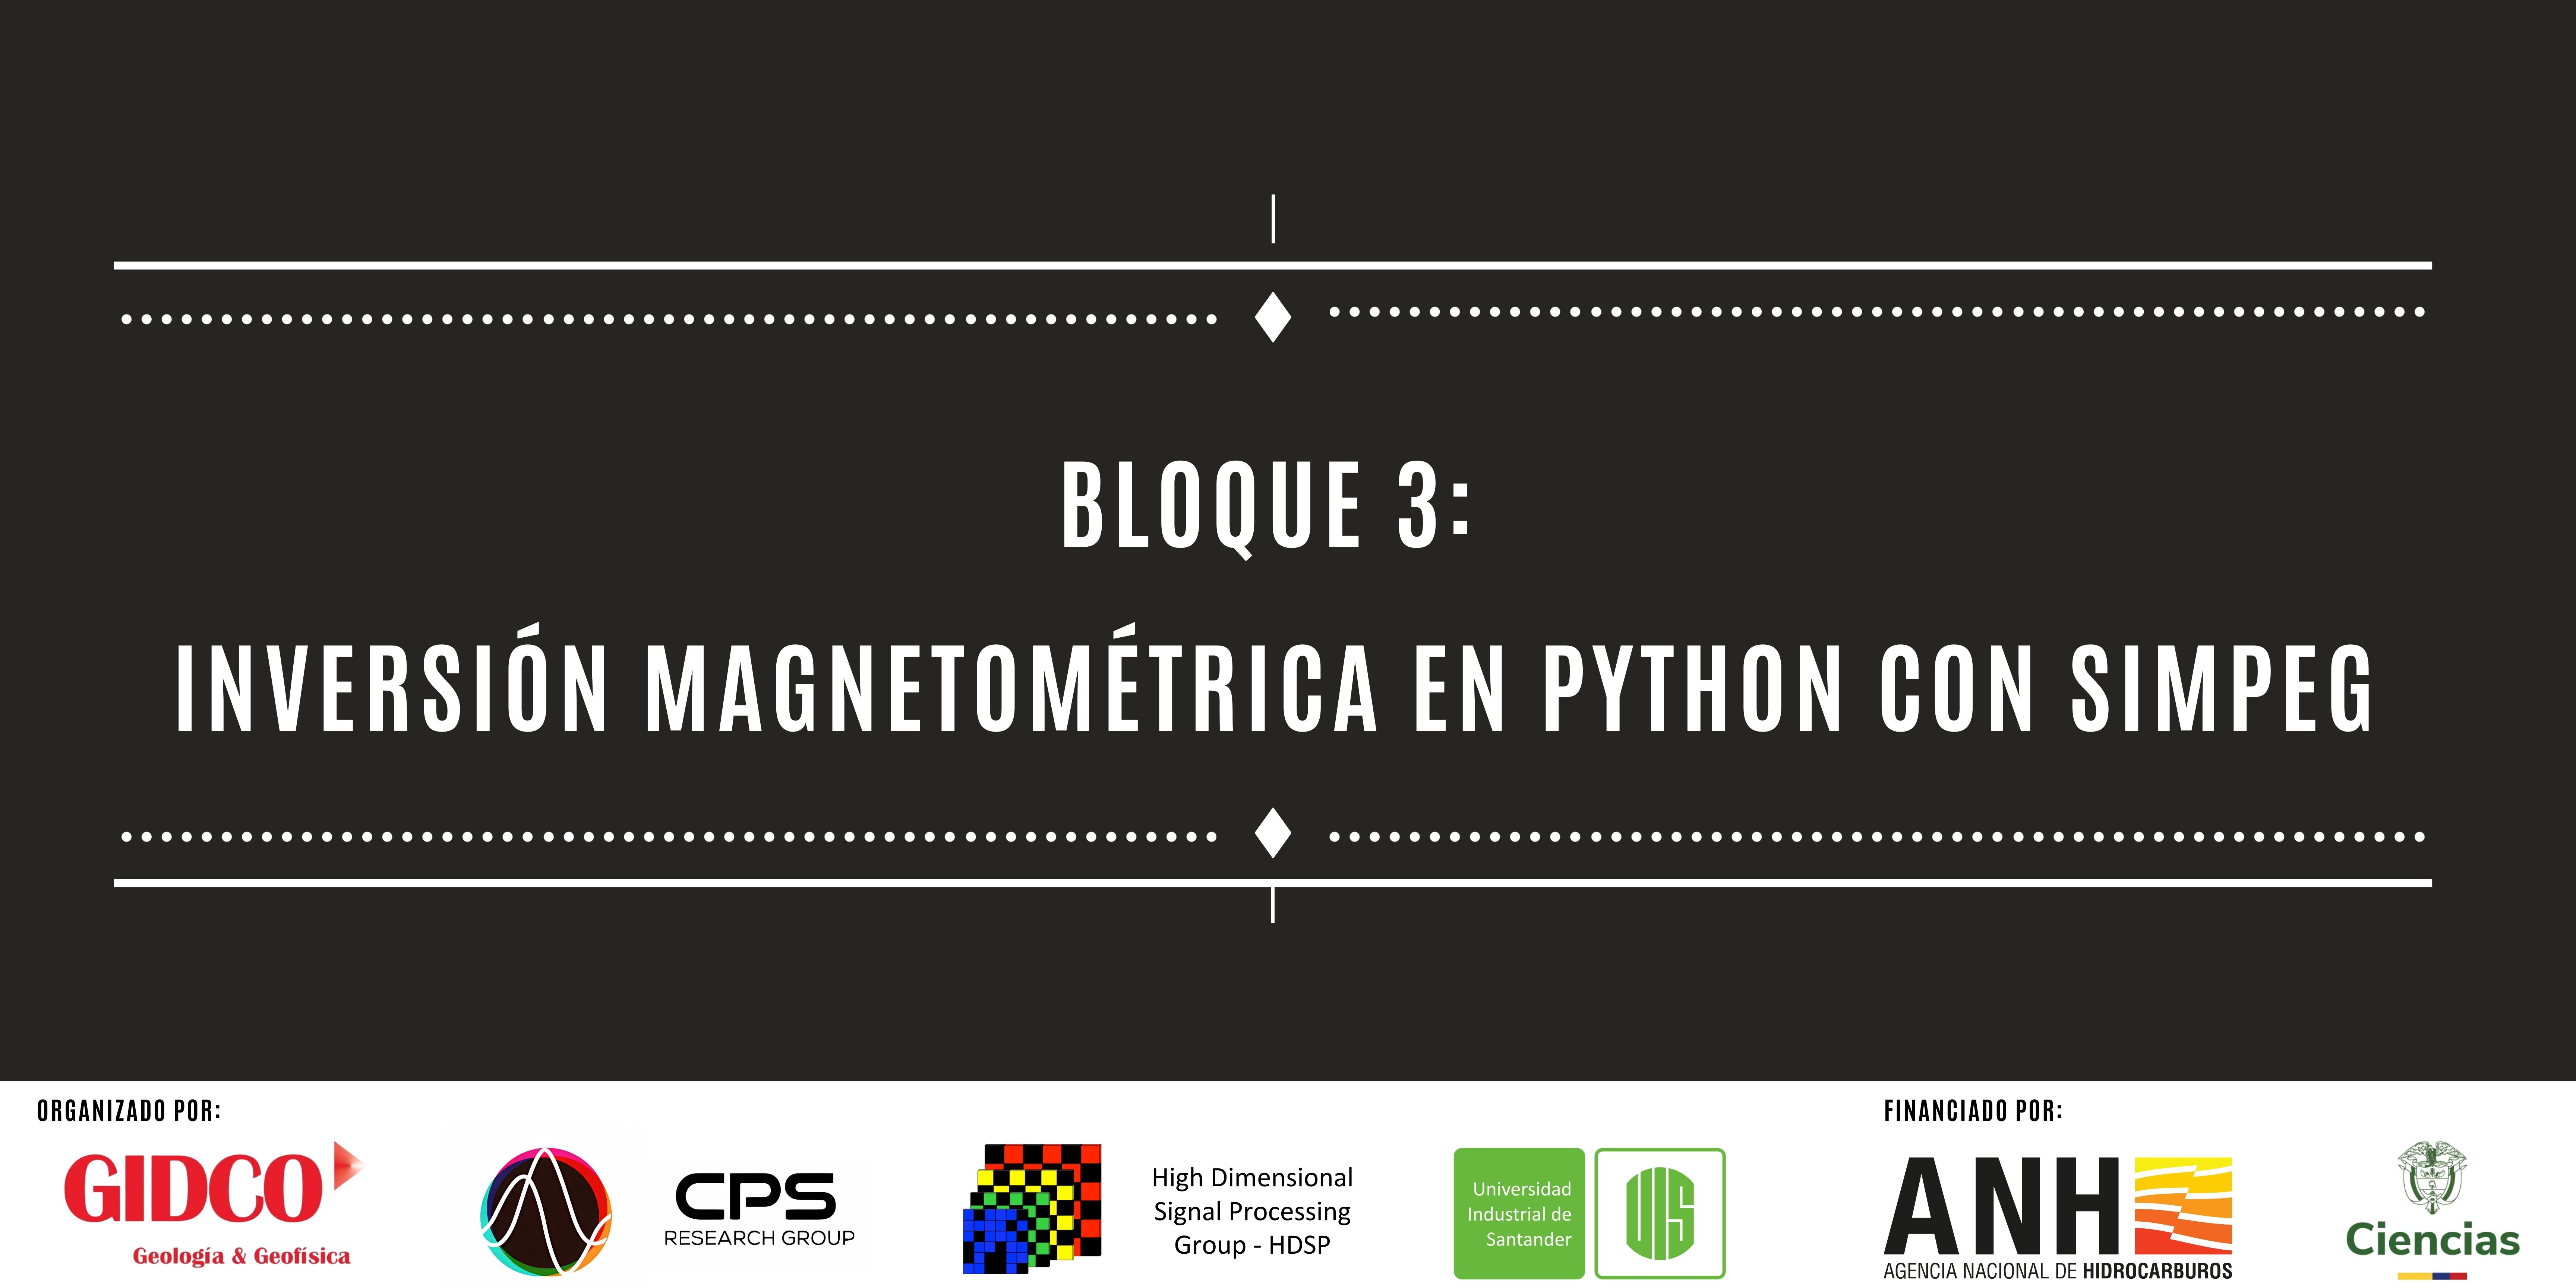

# Inversión magnetomértrica sintética con **SimPEG**

En este cuaderno se implementa un flujo reproducible de **inversión magnetométrica 3D** a partir de datos sintéticos de **Total Magnetic Intensity (TMI)**. El objetivo es estimar un modelo de **susceptibilidad magnética** en el subsuelo que explique las anomalías observadas, incorporando:

- Geometría de adquisición (ubicación de receptores y campo inducido).
- Topografía (para definir celdas activas: subsuelo vs aire).
- Modelo de incertidumbre (ponderación del ajuste).
- Regularización (estabilidad y control de complejidad).
- Métricas cuantitativas (ajuste a datos y, al ser sintético, calidad del modelo recuperado).

La formulación sigue la estructura estándar $J(\mathbf{m})=\phi_d(\mathbf{m})+\beta\,\phi_m(\mathbf{m})$, donde `m` es el vector de parámetros, $\phi_d$ mide el ajuste a datos y $\phi_m$ controla la complejidad del modelo.



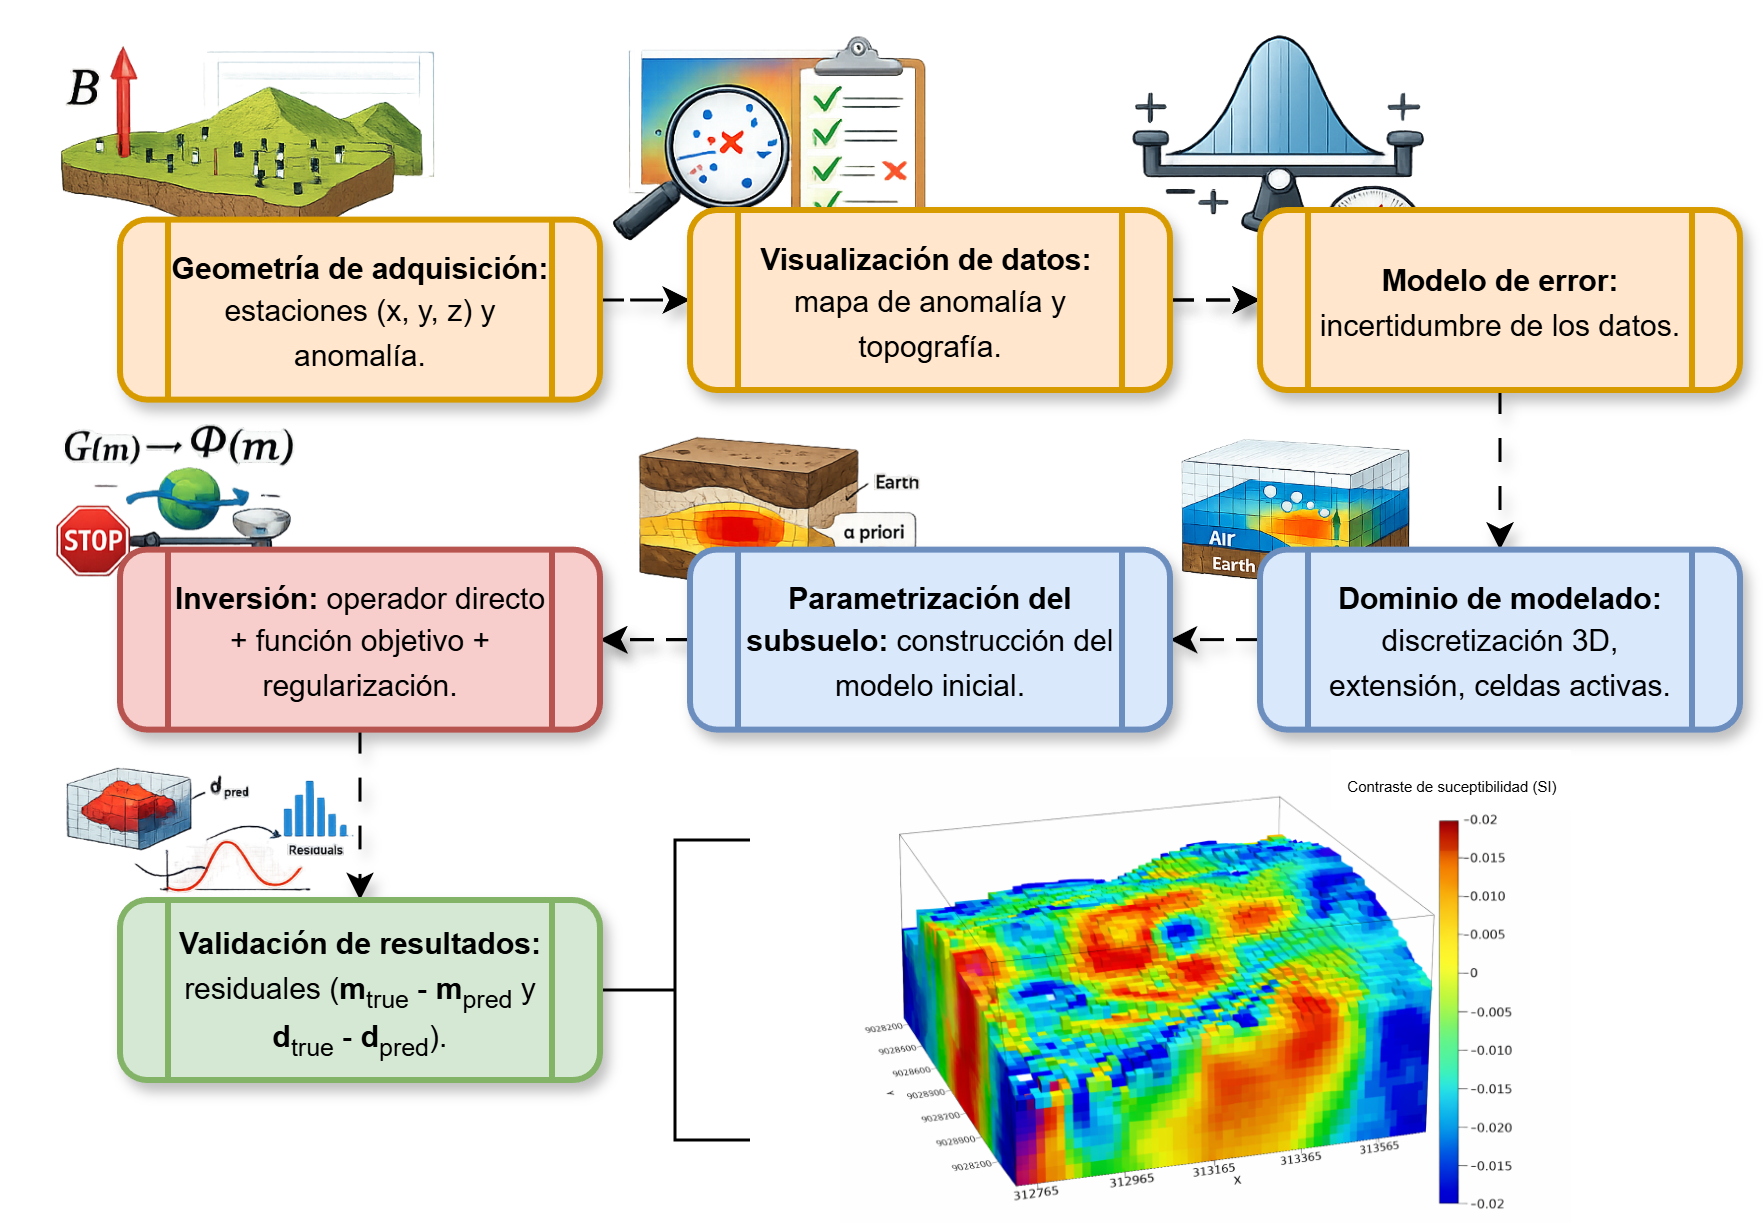

In [ ]:
!pip install simpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 12.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 13.4 MB/s eta 0:00:00
  Created wheel for simpeg: filename=simpeg-0.25.2-py3-none-any.whl size=595275 sha256=9e02e31a42418566e38ea05ba8b3ba461165f9dcb2958c384f83b04b2b7563de
  Stored in directory: /root/.cache/pip/wheels/8a/db/6f/b6da5be3c64674bd3af27db599ff3f633a39e325b67485a2f1
  Created wheel for pymatsolver: filename=pymatsolver-0.4.0-py3-none-any.whl size=15857 sha256=1f7303b2606f10997e848d7ad36423b58b494bb3b8a01a30ea7b6d20

## 0. Preparación del entorno e importación de librerías  

En esta sección preparamos el entorno de trabajo e importamos las librerías necesarias para realizar la simulación e inversión magnetométrica en 3D.

Si es necesario, primero se debe instalar **SimPEG**. Luego cargamos los módulos que utilizaremos a lo largo del notebook:

### Librerías principales

- **`discretize`**: creación y manejo de mallas 3D (`TensorMesh`) y definición de celdas activas.  
- **`simpeg`**: estructura completa de inversión (datos, función de desajuste, regularización, optimización, directivas e inversión).  
- **`simpeg.potential_fields.magnetics`**: simulación directa e inversión para datos de anomalía magnética.  
- **`matplotlib`**: visualización de modelos y datos.  
- **`numpy`**: operaciones numéricas.  

In [ ]:
# @title
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

from discretize import TensorMesh
from discretize.utils import active_from_xyz

import os
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

mpl.rcParams.update({"font.size": 14})
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 1. Descarga y carga de datos

Se utilizan archivos tipo **XYZ** provistos por el tutorial:

- Topografía: coordenadas $(x,y,z)$.
- Datos TMI: coordenadas $(x,y,z)$ y valor observado $d_{obs}$ en nT.

La descarga y extracción del paquete permite trabajar con un ejemplo autocontenido y reproducible, ideal para demostraciones metodológicas.


In [ ]:
data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/04-magnetics/inv_magnetics_induced_3d_files.tar.gz"  #@param {type:"string"}
OVERWRITE = True  #@param {type:"boolean"}

downloaded_data = download(data_source, overwrite=OVERWRITE)

tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()

dir_path = downloaded_data.split(".")[0] + os.path.sep

topo_filename = dir_path + "magnetics_topo.txt"
data_filename = dir_path + "magnetics_data.obs"

topo_xyz = np.loadtxt(str(topo_filename))                 # (Ntopo, 3)
dobs_all = np.loadtxt(str(data_filename))                 # (Nobs, 4) -> x,y,z,data

receiver_locations = dobs_all[:, 0:3]
dobs = dobs_all[:, -1]

print("Topografía:", topo_xyz.shape)
print("Datos TMI :", dobs_all.shape)
print("dobs min/max (nT):", float(np.min(dobs)), float(np.max(dobs)))

   saved to: /content/inv_magnetics_induced_3d_files.tar.gz
Download completed!
Topografía: (1681, 3)
Datos TMI : (289, 4)
dobs min/max (nT): 0.18027 22.189


/tmp/ipykernel_9062/1833570246.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


### Vista previa del formato de archivos (tablas)

Esto permite verificar rápidamente:
- columnas y unidades
- coherencia de coordenadas

In [ ]:
# @title
df_topo = pd.DataFrame(topo_xyz, columns=["x", "y", "z"])
df_obs  = pd.DataFrame(dobs_all, columns=["x", "y", "z", "dobs_nT"])

print("Topografía (primeras filas):")
display(df_topo.head(10))

print("Datos TMI (primeras filas):")
display(df_obs.head(10))

Topografía (primeras filas):


,x,y,z
0,-200.0,-200.0,100.19
1,-200.0,-190.0,100.45
2,-200.0,-180.0,100.00
3,-200.0,-170.0,100.08
4,-200.0,-160.0,100.04
5,-200.0,-150.0,100.17
6,-200.0,-140.0,100.19
7,-200.0,-130.0,100.21
8,-200.0,-120.0,100.21
9,-200.0,-110.0,100.02


Datos TMI (primeras filas):


,x,y,z,dobs_nT
0,-80.0,-80.0,108.35,1.84100
1,-70.0,-80.0,107.66,1.66810
2,-60.0,-80.0,106.95,1.10600
3,-50.0,-80.0,106.27,1.98930
4,-40.0,-80.0,105.71,1.00580
5,-30.0,-80.0,105.49,1.68040
6,-20.0,-80.0,104.84,1.61840
7,-10.0,-80.0,104.59,1.01050
8,0.0,-80.0,104.67,1.54160
9,10.0,-80.0,104.63,0.73603


# 2. Control de calidad visual (QC)

Antes de invertir, se inspeccionan:

- Cobertura espacial y distribución de estaciones `receiver_locations`.
- Amplitud y patrón de la anomalía `dobs`.
- Relieve `topo_xyz` para entender el límite aire–tierra.

La escala del mapa TMI se centra en cero con un rango simétrico $\pm \max(|d_{obs}|)$ para comparar claramente anomalías positivas y negativas.


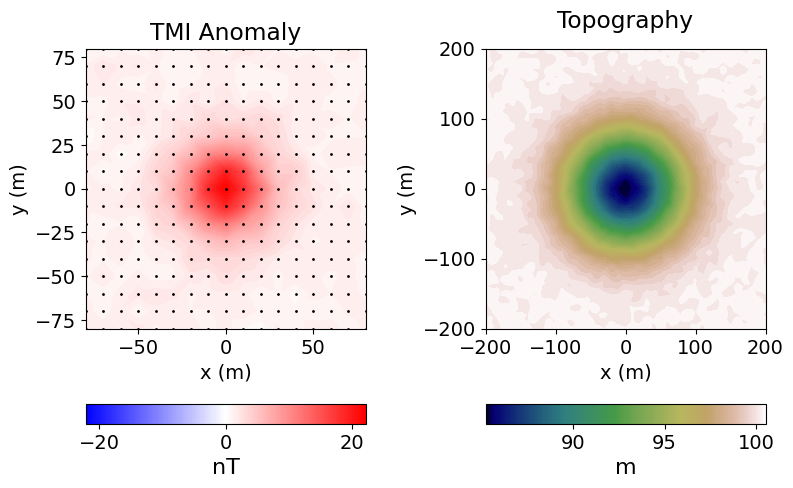

In [ ]:
NCONTOUR_TMI = 40  #@param {type:"integer", min:5, max:200, step:5}
NCONTOUR_TOPO = 50 #@param {type:"integer", min:5, max:200, step:5}

fig = plt.figure(figsize=(8, 5))

ax1 = fig.add_axes([0.05, 0.35, 0.35, 0.6])
v_max = np.max(np.abs(dobs))
norm1 = mpl.colors.Normalize(vmin=-v_max, vmax=v_max)

plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    dataloc=True,
    ncontour=NCONTOUR_TMI,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm1},
)
ax1.set_title("TMI Anomaly")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

cx1 = fig.add_axes([0.05, 0.18, 0.35, 0.04])
cbar1 = mpl.colorbar.ColorbarBase(cx1, norm=norm1, orientation="horizontal", cmap=mpl.cm.bwr)
cbar1.set_label("nT", size=16)

ax2 = fig.add_axes([0.55, 0.35, 0.35, 0.6])
plot2Ddata(
    topo_xyz[:, 0:2],
    topo_xyz[:, -1],
    ax=ax2,
    ncontour=NCONTOUR_TOPO,
    contourOpts={"cmap": "gist_earth"},
)
ax2.set_title("Topography", pad=15)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

cx2 = fig.add_axes([0.55, 0.18, 0.35, 0.04])
norm2 = mpl.colors.Normalize(vmin=np.min(topo_xyz[:, -1]), vmax=np.max(topo_xyz[:, -1]))
cbar2 = mpl.colorbar.ColorbarBase(cx2, norm=norm2, orientation="horizontal", cmap=mpl.cm.gist_earth)
cbar2.set_label("m", size=16)

plt.show()

## 3. Incertidumbres y ponderación (notación tipo GIFtools)

Misfit ponderado:
$$
\phi_d(\mathbf{m})=
\sum_{i=1}^{N}\left(\frac{F(\mathbf{m})_i-d_i}{\varepsilon_i}\right)^2
=
\left\|\mathbf{W}_d\left(\mathbf{d}-\mathbf{F}(\mathbf{m})\right)\right\|_2^2,
\qquad
\mathbf{W}_d=\mathrm{diag}(\varepsilon_i^{-1})
$$

Aquí usamos un *floor* constante:
$$
\varepsilon_i = \sigma \quad \forall i
$$

In [ ]:
FLOOR_FRAC = 0.02  #@param {type:"number", min:0, max:0.5, step:0.005}

maximum_anomaly = np.max(np.abs(dobs))
floor_uncertainty = FLOOR_FRAC * maximum_anomaly
uncertainties = floor_uncertainty * np.ones_like(dobs)

print(f"Floor uncertainty: {floor_uncertainty:.6g} nT")

Floor uncertainty: 0.44378 nT


# 4. Survey y objeto Data

Se construye el experimento magnetométrico:

- Componentes: `components = ["tmi"]`
- Receptores: `receiver_locations`
- Campo inducido uniforme: amplitud, inclinación y declinación (`amplitude`, `inclination`, `declination`)

Con ello se define `survey` y el objeto `data_object`, que integra $d_{obs}$, $\sigma$ y la geometría/física del problema.


In [ ]:
components = ["tmi"]

inclination = 90   #@param {type:"number", min:-90, max:90, step:1}
declination = 0    #@param {type:"number", min:-180, max:180, step:1}
amplitude = 50000  #@param {type:"number", min:0, max:200000, step:1000}

receiver_obj = magnetics.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_obj]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

survey = magnetics.survey.Survey(source_field)
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

## 5. Malla y celdas activas

Se crea una `TensorMesh` (zona central + padding).  
Luego se define la máscara de celdas activas bajo topografía: subsuelo vs aire.

En este ejemplo se ajusta el origen en Z para que la parte superior de la malla quede por encima de la topografía.

In [ ]:
dh = 5.0  #@param {type:"number", min:1, max:100, step:1}

pad_cells = 5   #@param {type:"integer", min:1, max:40, step:1}
core_cells = 40 #@param {type:"integer", min:5, max:200, step:5}
pad_rate = 1.3  #@param {type:"number", min:1.05, max:2.0, step:0.05}

nz_pad = 5   #@param {type:"integer", min:1, max:40, step:1}
nz_core = 15 #@param {type:"integer", min:5, max:200, step:5}

hx = [(dh, pad_cells, -pad_rate), (dh, core_cells), (dh, pad_cells, pad_rate)]
hy = [(dh, pad_cells, -pad_rate), (dh, core_cells), (dh, pad_cells, pad_rate)]
hz = [(dh, nz_pad, -pad_rate), (dh, nz_core)]

tensor_mesh = TensorMesh([hx, hy, hz], "CCN")
tensor_mesh.origin += np.r_[0.0, 0.0, topo_xyz[:, -1].max()]

active_tensor_cells = active_from_xyz(tensor_mesh, topo_xyz)
n_tensor_active = int(active_tensor_cells.sum())
print(f"Active cells: {n_tensor_active} / {tensor_mesh.nC}")

Active cells: 47761 / 50000


# 6. Celdas activas, mapeos y modelo inicial

Se definen:

- Modelo inicial `starting_tensor_model`: pequeño y no nulo (evita gradiente cero al inicio).
- Modelo de referencia `reference_tensor_model`: típicamente cero si no hay información a-priori.
- Mapa de ploteo `tensor_plotting_map`: inserta `NaN` en celdas inactivas para visualizar cortes sin “aire”.


In [ ]:
STARTING_VALUE = 1e-6  #@param {type:"number"}
tensor_model_map = maps.IdentityMap(nP=n_tensor_active)

starting_tensor_model = STARTING_VALUE * np.ones(n_tensor_active)
reference_tensor_model = np.zeros_like(starting_tensor_model)

tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_tensor_cells, np.nan)

### Corte 2D: topografía + malla + activas/inactivas (qué se invierte y qué no)

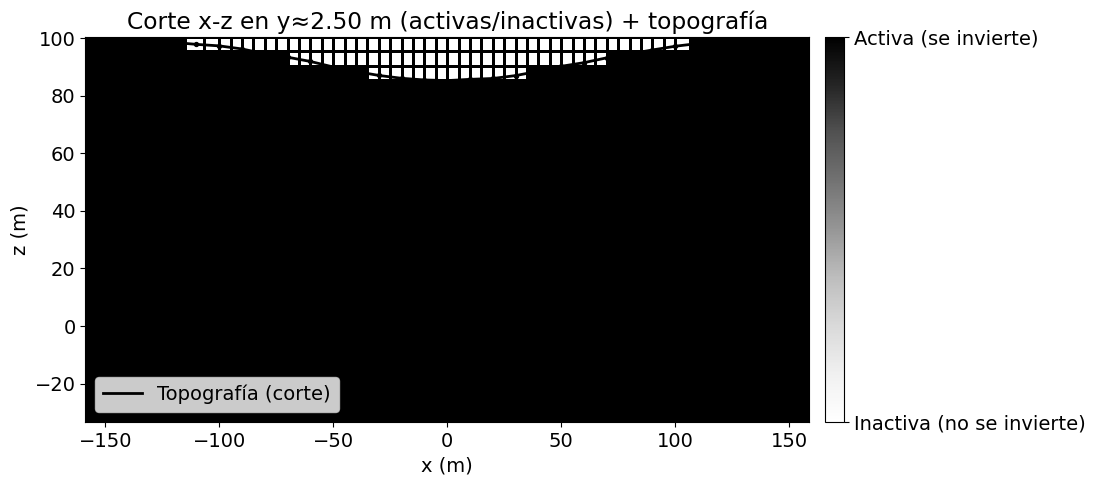

In [ ]:
SLICE_Y_LOC = 0.0  #@param {type:"number", min:-500, max:500, step:5}

y_centers = tensor_mesh.cell_centers[:, 1]
y0 = y_centers[np.argmin(np.abs(y_centers - SLICE_Y_LOC))]

active_full = np.zeros(tensor_mesh.nC)
active_full[active_tensor_cells] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

out = tensor_mesh.plot_slice(
    active_full,
    normal="Y",
    slice_loc=y0,
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "Greys", "vmin": 0, "vmax": 1},
)
cbar = plt.colorbar(out[0], ax=ax, fraction=0.046, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactiva (no se invierte)", "Activa (se invierte)"])

tol = max(tensor_mesh.h[1].min(), 5.0)
mask_topo = np.abs(topo_xyz[:, 1] - y0) < tol
topo_cut = topo_xyz[mask_topo]

if topo_cut.shape[0] > 5:
    topo_cut = topo_cut[np.argsort(topo_cut[:, 0])]
    ax.plot(topo_cut[:, 0], topo_cut[:, 2], "k-", lw=2, label="Topografía (corte)")
    ax.scatter(topo_cut[:, 0], topo_cut[:, 2], s=8, c="k")
    ax.legend(loc="lower left")
else:
    ax.text(
        0.02, 0.95,
        "Pocos puntos de topografía en este corte.\nPrueba otro SLICE_Y_LOC.",
        transform=ax.transAxes, va="top"
    )

ax.set_title(f"Corte x-z en y≈{y0:.2f} m (activas/inactivas) + topografía")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.show()

# 7. Verificación del modelo inicial (slice)

Se grafica un corte 2D del modelo inicial para validar:

- Extensión del dominio y orientación de ejes.
- Correcta aplicación de celdas activas vs inactivas.
- Relación entre topografía y discretización.

Este chequeo evita errores comunes de malla/posicionamiento antes de ejecutar la inversión.


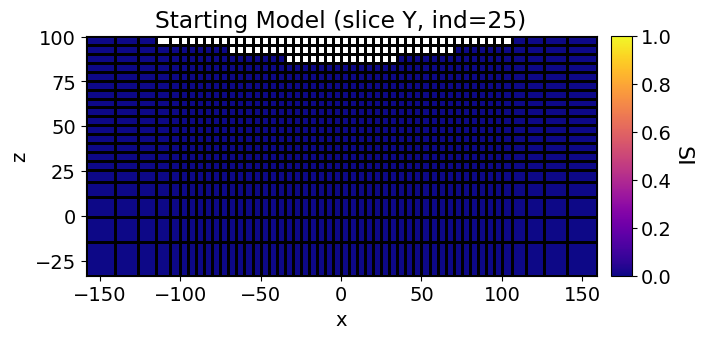

In [ ]:
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

SLICE_NORMAL = "Y"  #@param ["X","Y","Z"]

# Para normal="Y", ind es índice de y; para X/Z análogo
SLICE_IND = int(tensor_mesh.shape_cells[1] / 2)  #@param {type:"integer", min:0, max:1000, step:1}

fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

tensor_mesh.plot_slice(
    tensor_plotting_map * starting_tensor_model,
    normal=SLICE_NORMAL,
    ax=ax1,
    ind=SLICE_IND,
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title(f"Starting Model (slice {SLICE_NORMAL}, ind={SLICE_IND})")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma)
cbar.set_label("SI", rotation=270, labelpad=15, size=16)

plt.show()

## 8. Formulación de la inversión (subdividida)

Función objetivo:
$$
J(\mathbf{m})=\phi_d(\mathbf{m})+\beta\,\phi_m(\mathbf{m})
$$

### Operador directo magnetométrico (TMI)

Magnetización inducida (modelo escalar):
$$
\mathbf{M}(\mathbf{r})=\kappa(\mathbf{r})\,\mathbf{H}_0
$$

Campo magnético inducido (forma integral, operador lineal en $\kappa$:
$$
\Delta \mathbf{B}(\mathbf{r}_i)=
\mu_0 \int_V \mathbf{K}(\mathbf{r}_i,\mathbf{r}')\,\mathbf{M}(\mathbf{r}')\,dV'
$$

TMI (aprox. proyección sobre el campo principal):
$$
d_i \approx \hat{\mathbf{b}}_0^{\mathsf{T}}\Delta \mathbf{B}(\mathbf{r}_i)
$$

Discretización:
$$
\mathbf{d}=\mathbf{G}\mathbf{m}
$$

En el código, `Simulation3DIntegral(..., model_type="scalar")` implementa el mapeo \(\mathbf{m}\mapsto \mathbf{d}_{pred}\) para TMI inducido.

### 8.1) Forward + misfit (WLS)

In [ ]:
simulation_L2 = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=tensor_model_map,
    active_cells=active_tensor_cells,
)

dmis_L2 = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_L2)
print("Forward + misfit listos.")

Forward + misfit listos.


### 8.2 Regularización (notación tipo GIFtools)

Una forma estándar (Tikhonov) puede escribirse como:
$$
\phi_m(\mathbf{m}) \approx
\alpha_s\|\mathbf{W_s}(\mathbf{m}-\mathbf{m}_{ref})\|_2^2+
\alpha_x\|\mathbf{W_x}\nabla_x\mathbf{m}\|_2^2+
\alpha_y\|\mathbf{W_y}\nabla_y\mathbf{m}\|_2^2+
\alpha_z\|\mathbf{W_z}\nabla_z\mathbf{m}\|_2^2
$$

En el código:
- `WeightedLeastSquares(..., length_scale_x,y,z, reference_model=...)` construye smallness + suavidad.  
- `length_scale_*` controla la escala de suavidad (penalización de gradientes).

In [ ]:
length_scale_x = 1.0  #@param {type:"number", min:0.1, max:100.0, step:0.1}
length_scale_y = 1.0  #@param {type:"number", min:0.1, max:100.0, step:0.1}
length_scale_z = 1.0  #@param {type:"number", min:0.1, max:100.0, step:0.1}

reg_L2 = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_tensor_cells,
    length_scale_x=length_scale_x,
    length_scale_y=length_scale_y,
    length_scale_z=length_scale_z,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=False,
)

print("Regularización lista.")

Regularización lista.


### 8.3 Optimizador (ProjectedGNCG) con bounds

En susceptibilidad inducida, es común imponer $\kappa \ge 0$, por eso `lower=0`.

In [ ]:
maxIter = 100      #@param {type:"integer", min:1, max:500, step:1}
lower = 0.0        #@param {type:"number", min:0.0, max:10.0, step:0.001}
maxIterLS = 20     #@param {type:"integer", min:1, max:200, step:1}
cg_maxiter = 10    #@param {type:"integer", min:1, max:500, step:1}
cg_rtol = 1e-2     #@param {type:"number"}

opt_L2 = optimization.ProjectedGNCG(
    maxIter=maxIter,
    lower=lower,
    maxIterLS=maxIterLS,
    cg_maxiter=cg_maxiter,
    cg_rtol=cg_rtol
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)
print("Optimizador y BaseInvProblem listos.")

Optimizador y BaseInvProblem listos.


### 8.4 Directivas (β, agenda, target misfit, precondicionador)

- `BetaEstimate_ByEig`: estima $\beta_0$
- `BetaSchedule`: enfría $\beta$
- `TargetMisfit`: detiene cuando $\phi_d \approx N$
- `UpdatePreconditioner`: acelera la solución
- `UpdateSensitivityWeights`: estabiliza amplitudes (opcional por iteración)

In [ ]:
beta0_ratio = 10.0     #@param {type:"number", min:1e-3, max:1e3, step:0.5}
coolingFactor = 2.0    #@param {type:"number", min:1.0, max:10.0, step:0.1}
coolingRate = 1        #@param {type:"integer", min:1, max:10, step:1}
chifact = 1.0          #@param {type:"number", min:0.1, max:10.0, step:0.1}

SENS_EVERY_ITER = False  #@param {type:"boolean"}
JACOBI_EVERY_ITER = True #@param {type:"boolean"}

sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=SENS_EVERY_ITER)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=JACOBI_EVERY_ITER)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)
beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
target_misfit = directives.TargetMisfit(chifact=chifact)

directives_list_L2 = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)
print("Directivas listas.")

Directivas listas.


# 9. Ejecución de la inversión y predicción

Se ejecuta `inv_L2.run(starting_tensor_model)` para obtener el modelo recuperado `recovered_tensor_model`.

Con el modelo final se calcula la predicción `dpred`, que permite:

- Evaluar residuales $r = d_{obs}-d_{pred}$,
- Analizar mapas observado vs predicho,
- Calcular métricas de desempeño.


In [ ]:
recovered_tensor_model = inv_L2.run(starting_tensor_model)

# Predicción final
dpred = inv_prob_L2.dpred  # (si alguna vez ves signo raro, revisa convención, pero aquí es estándar)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 289.0
INFO:SimPEG:Directive TargetMisfit: Target data misfit is 289.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  4.00e+05  2.68e+04  3.01e-07  2.68e+04                         0           inf          inf                
   1  4.00e+05  3.23e+03  7.79e-03  6.34e+03    1.75e+06      0      10       2.07e-01     3.73e+05              
   2  2.00e+05  7.92e+02  1.19e-02  3.18e+03    4.92e+05      0      7        7.00e-03     3.44e+03              
   3  1.00e+05  4.08e+02  1.45e-02  1.86e+03    1.21e+05      0      9        6.79e-03     8.19e+02              
   4  5.00e+04  2.46e+02  1.67e-02  1.08e+03    7.04e+04      0      10       1.05e-02     7.43e+02              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.3450e+01 <=

# 10. Métricas de ajuste a datos

Se define el residual:

$r_i = d_{obs,i} - d_{pred,i}$

y se calculan:

- $RMSE=\sqrt{\frac{1}{N}\sum_{i=1}^{N} r_i^2}$
- $MAE=\frac{1}{N}\sum_{i=1}^{N}|r_i|$

Además, usando el misfit reportado por SimPEG:

- $\chi^2_{red}=\frac{\phi_d}{N}$, con `phi_d = inv_prob_L2.dmisfit(recovered_tensor_model)`.

Interpretación: si $\chi^2_{red}\approx 1$, el nivel de ruido asumido en `uncertainties` es consistente con el ajuste alcanzado.


In [ ]:
res = dobs - dpred
N = res.size

sigma = uncertainties
sigma_safe = np.where(sigma == 0, np.nan, sigma)

rmse = np.sqrt(np.mean(res**2))
mae = np.mean(np.abs(res))
rmse_w = np.sqrt(np.nanmean((res / sigma_safe) ** 2))

phi_d = inv_prob_L2.dmisfit(recovered_tensor_model)
chi2_red = phi_d / N

print("\n===== MÉTRICAS DE AJUSTE (DATOS) =====")
print(f"RMSE              : {rmse:.6f} nT")
print(f"MAE               : {mae:.6f} nT")
print(f"Chi^2 reducido    : {chi2_red:.6f}  (phi_d/N)")


===== MÉTRICAS DE AJUSTE (DATOS) =====
RMSE              : 0.409803 nT
MAE               : 0.318310 nT
Chi^2 reducido    : 0.852736  (phi_d/N)


# 11. Diagnóstico espacial: observado, predicho y residual

Se presentan tres mapas 2D:

1. Observado `dobs`
2. Predicho `dpred`
3. Misfit `dobs - dpred`

Criterio visual:

- Observado y predicho con la misma escala $\pm \max(|d_{obs}|)$ para comparar amplitudes.
- Residual con su propia escala $\pm \max(|r|)$ para resaltar patrones sistemáticos.

Si el residual muestra estructura espacial, puede sugerir necesidad de ajustar `uncertainties`, refinar malla o enriquecer la parametrización (p.ej. remanencia).


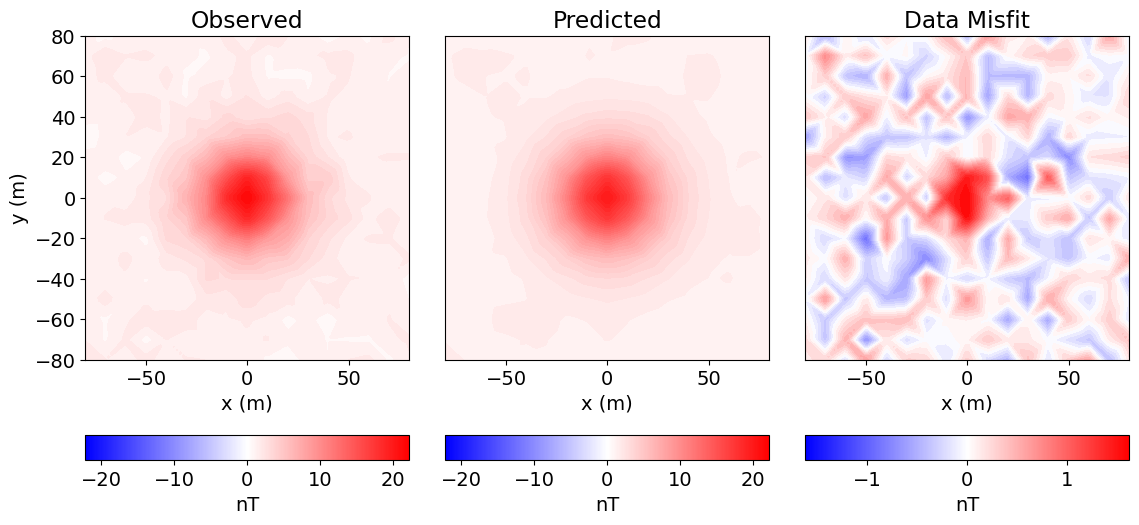

In [ ]:
# @title
data_array = np.c_[dobs, dpred, res]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]

v_lim = [
    np.max(np.abs(dobs)),
    np.max(np.abs(dobs)),
    np.max(np.abs(res)),
]

for ii in range(3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr)
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

# 12. Modelo verdadero (sintético)

Como el caso es sintético, se reconstruye `true_model` para validar recuperación:

- Fondo homogéneo `background_susceptibility`
- Contraste en una esfera con `sphere_susceptibility`

Esto permite evaluar objetivamente si el modelo recuperado reproduce geometría y amplitud del blanco.


In [ ]:
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

true_model = background_susceptibility * np.ones(n_tensor_active)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, tensor_mesh.cell_centers[active_tensor_cells]
)
true_model[ind_sphere] = sphere_susceptibility

# 13. Métricas en el modelo (True vs Recovered)

Se define el error de modelo en celdas activas:

$\Delta m = m^* - m_{true}$

y se calculan:

- $RMSE_m=\sqrt{\frac{1}{N}\sum (\Delta m)^2}$
- $MAE_m=\frac{1}{N}\sum|\Delta m|$

Estas métricas solo aplican cuando `true_model` es conocido (caso sintético). En datos reales, la validación se apoya en coherencia geológica y análisis del residual.


In [ ]:
m_res = recovered_tensor_model - true_model
valid_m = np.isfinite(true_model) & np.isfinite(recovered_tensor_model)

rmse_m = np.sqrt(np.mean((m_res[valid_m]) ** 2))
mae_m = np.mean(np.abs(m_res[valid_m]))

print("\n===== MÉTRICAS (MODELO) =====")
print(f"RMSE modelo        : {rmse_m:.6e} SI")
print(f"MAE  modelo        : {mae_m:.6e} SI")


===== MÉTRICAS (MODELO) =====
RMSE modelo        : 4.890041e-04 SI
MAE  modelo        : 1.292512e-04 SI


# 14. Comparación final (corte 2D)

Se comparan cortes 2D del:

- Modelo verdadero `true_model`
- Modelo recuperado `recovered_tensor_model`

Esto permite observar:

- Suavizado inducido por `reg_L2`,
- Tendencia típica en potenciales a ubicar estructura cerca de superficie,
- Capacidad para recuperar la geometría principal del objetivo.

Este cierre combina: (i) ajuste cuantitativo a datos y (ii) evaluación visual/objetiva de la recuperación del modelo.


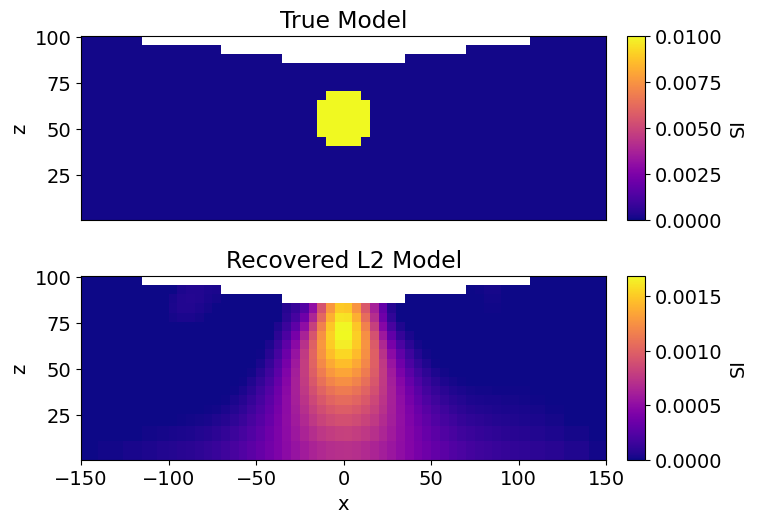

In [ ]:
XLIM = [-150, 150]  #@param
ZPAD = 100          #@param {type:"number", min:0, max:1000, step:10}

mesh_list = [tensor_mesh, tensor_mesh]
ind_list = [active_tensor_cells, active_tensor_cells]
model_list = [true_model, recovered_tensor_model]
title_list = ["True Model", "Recovered L2 Model"]

fig = plt.figure(figsize=(7, 8))
ax1 = [fig.add_axes([0.1, 0.7 - 0.3 * ii, 0.75, 0.23]) for ii in range(2)]
ax2 = [fig.add_axes([0.88, 0.7 - 0.3 * ii, 0.025, 0.23]) for ii in range(2)]

for ii, mesh in enumerate(mesh_list):
    plotting_map = maps.InjectActiveCells(mesh, ind_list[ii], np.nan)
    vmax = np.max(np.abs(model_list[ii]))
    norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)

    mesh.plot_slice(
        plotting_map * model_list[ii],
        normal="Y",
        ax=ax1[ii],
        ind=int(mesh.shape_cells[1] / 2),
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )
    ax1[ii].set_xlim(XLIM)
    ax1[ii].set_ylim([topo_xyz[:, -1].max() - ZPAD, topo_xyz[:, -1].max()])
    if ii == 0:
        ax1[ii].set_xlabel("")
        ax1[ii].set_xticks([])
    ax1[ii].set_title(title_list[ii])

    cbar = mpl.colorbar.ColorbarBase(ax2[ii], norm=norm, orientation="vertical", cmap=mpl.cm.plasma)
    cbar.set_label("SI", labelpad=5)

plt.show()